3.10.6
1923024.0


/home/ebertp/work/software/miniforge3/envs/nbsrv/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/ebertp/work/software/miniforge3/envs/nbsrv/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate o

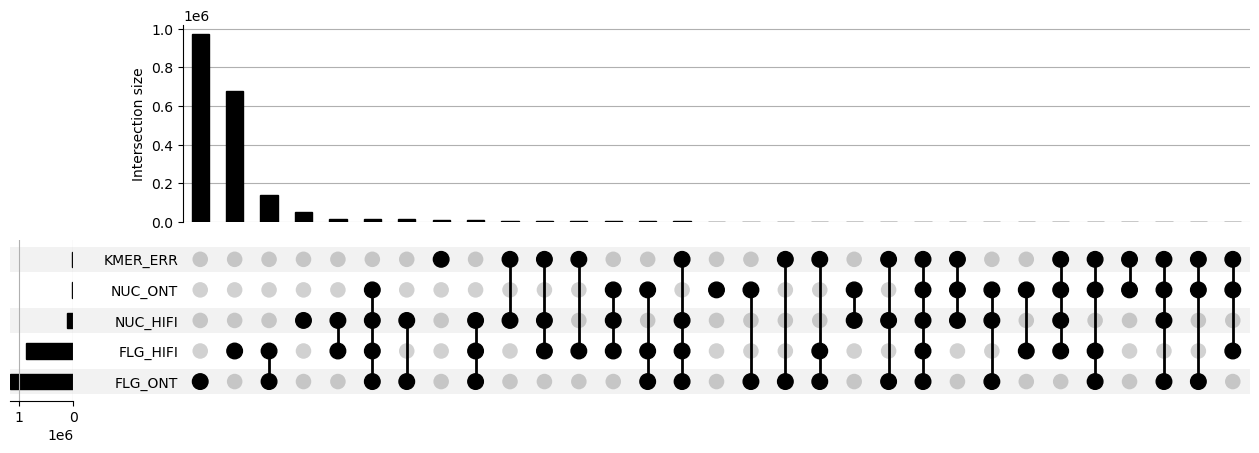

In [5]:
import pathlib as pl

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

# NB-specific code

import pandas as pd
import numpy as np
import numpy.ma as msk
import pathlib as pl
import upsetplot as ups
import collections as col
import operator as op
import pickle as pkl
import itertools as itt
import functools as fnt

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt

print(mpl.__version__)

plot_data = DATA_ROOT.joinpath("wf-data/region-labels/qc_windows/tables")

cache_file = NB_CACHE_FOLDER.joinpath("err_stats_cache.tsv.gz")

window_clean_columns = [
    "flagger_hifi_is_clean",
    "flagger_ont_is_clean",
    "nucflag_hifi_is_clean",
    "nucflag_ont_is_clean",
    "kmer_errors_is_clean"
]

renamed = [
    "FLG_HIFI",
    "FLG_ONT",
    "NUC_HIFI",
    "NUC_ONT",
    "KMER_ERR"
]

renamer = dict((old, new) for old, new in zip(window_clean_columns, renamed))


def pct(enum, denum):
    return round(enum/denum*100, 3)


def get_combo(row):
    v1 = getattr(row, renamed[0])
    v2 = getattr(row, renamed[1])
    v3 = getattr(row, renamed[2])
    v4 = getattr(row, renamed[3])
    v5 = getattr(row, renamed[4])
    # this is all 0 or 1
    label = f"{v1}{v2}{v3}{v4}{v5}"
    #return v1, v2, v3, v4
    return label


def get_label_combos():

    combos = []
    for i in [0,1]:
        for j in [0,1]:
            for k in [0,1]:
                for l in [0,1]:
                    for m in [0,1]:
                        combos.append(f"{i}{j}{k}{l}{m}")
    return sorted(set(combos))


midx_names = ["sample", "seq", "statistic", "label"]
def collect_data(data_folder):

    # columns - rank bins
    # rows - multi-idx
    # idx values:
    # 1 sample
    # 2 total_count
    # 3 clean_count
    # 4 flagged_count
    # 5 clean_pct
    # 6 flagged_pct
    # 7 label

    cohort_data = []

    label_combos = get_label_combos()
    
    for tsv_file in data_folder.glob("*.tsv"):
        sample_data = None       
        sample = tsv_file.name.split("_")[0]
        sample_total_key = (sample, "main", "total_count", "global")
        
        df = pd.read_csv(tsv_file, sep="\t", header=0)

        # consider only main sequence
        df = df.loc[df["#seq"].str.endswith("_chrY"), :].copy()
        df.drop(["#seq", "start", "end"], axis=1, inplace=True)
        assert df.shape[0] == df["window"].nunique()

        sample_data = df.groupby("rank_bin").size().to_frame().transpose()
        midx = pd.MultiIndex.from_tuples(
            [sample_total_key],
            names=midx_names
        )
        sample_data = sample_data.set_index(midx, inplace=False)
        
        # compute clean windows
        all_clean_select = (df[window_clean_columns] == 1).all(axis=1)
        agg_data = df.loc[all_clean_select, :].groupby("rank_bin").size().to_frame().transpose()
        midx = pd.MultiIndex.from_tuples(
            [(sample, "main", "clean_count", "global")],
            names=midx_names
        )
        agg_data = agg_data.set_index(midx, inplace=False)
        sample_data = pd.concat([sample_data, agg_data], axis=0, ignore_index=False)
        
        agg_pct = (agg_data.div(sample_data.xs(sample_total_key)) * 100).round(2)
        midx = pd.MultiIndex.from_tuples(
            [(sample, "main", "clean_pct", "global")],
            names=midx_names
        )
        agg_pct = agg_pct.set_index(midx, inplace=False)
        sample_data = pd.concat([sample_data, agg_pct], axis=0, ignore_index=False)
        
        # compute any flagged windows
        agg_data = df.loc[~all_clean_select, :].groupby("rank_bin").size().to_frame().transpose()
        midx = pd.MultiIndex.from_tuples(
            [(sample, "main", "flagged_count", "global")],
            names=midx_names
        )
        agg_data = agg_data.set_index(midx, inplace=False)
        sample_data = pd.concat([sample_data, agg_data], axis=0, ignore_index=False)
        
        agg_pct = (agg_data.div(sample_data.xs(sample_total_key)) * 100).round(2)
        midx = pd.MultiIndex.from_tuples(
            [(sample, "main", "flagged_pct", "global")],
            names=midx_names
        )
        agg_pct = agg_pct.set_index(midx, inplace=False)
        sample_data = pd.concat([sample_data, agg_pct], axis=0, ignore_index=False)
        sample_data.fillna(0., inplace=True)

        # compute flagged by bin and label
        # simplify column labels
        df.rename(renamer, axis=1, inplace=True)

        df["label"] = df.apply(get_combo, axis=1)
        if df["label"].nunique() != len(label_combos):
            missing_combos = set(label_combos) - set(df["label"].unique())
            
        label_counts_per_bin = df.groupby(
            "rank_bin"
        )["label"].value_counts().reset_index(drop=False, inplace=False)
        midx = pd.MultiIndex.from_tuples(
            [
                (sample, "main", "label_count", row.label)
                for row in label_counts_per_bin.itertuples()
            ],
            names=midx_names
        )
        label_counts_per_bin.set_index(midx, inplace=True)
        label_counts_per_bin.drop("label", axis=1, inplace=True)
        label_counts_per_bin = label_counts_per_bin.pivot_table(
            index=label_counts_per_bin.index,
            columns="rank_bin",
            values="count",
            aggfunc=lambda x: x  # "identity" function
        )
        label_counts_per_bin.set_index(
            pd.MultiIndex.from_tuples(
                label_counts_per_bin.index,
                names=midx_names
            ), inplace=True
        )
        label_counts_per_bin.fillna(0., inplace=True)
        sample_data = pd.concat([sample_data, label_counts_per_bin], axis=0, ignore_index=False)
        sample_data.fillna(0., inplace=True)
        
        label_pct = ((label_counts_per_bin.div(sample_data.xs(sample_total_key))) * 100).round(2)
        label_pct.set_index(
            pd.MultiIndex.from_tuples(
                [
                    (sample, "main", "label_pct", t[-1])
                    for t in label_pct.index.to_list()
                ],
                names=midx_names
            ),
            inplace=True
        )
        sample_data = pd.concat([sample_data, label_pct], axis=0, ignore_index=False)
        sample_data.fillna(0., inplace=True)
        if missing_combos:
            add_zeros = np.zeros((len(missing_combos) * 2,101), dtype=float)
            zero_index = []
            for stat in ["label_count", "label_pct"]:
                for label in sorted(missing_combos):
                    zero_index.append(
                        (sample, "main", stat, label) 
                    )
            add_zeros = pd.DataFrame(
                add_zeros, columns=range(0,101),
                index=pd.MultiIndex.from_tuples(zero_index, names=midx_names)
            )
            sample_data = pd.concat([sample_data, add_zeros], axis=0, ignore_index=False)

        level_values = set(sample_data.index.get_level_values("label"))
        assert len(level_values) == len(label_combos) + 1
        # adjusted for label 'global'
        
        cohort_data.append(sample_data)

    cohort_data = pd.concat(cohort_data, axis=0, ignore_index=False)
    return cohort_data

FORCE_REBUILD_CACHE = False

if cache_file.is_file() and not FORCE_REBUILD_CACHE:
    err_stats = pd.read_csv(
        cache_file, sep="\t",
        header=0,
        index_col=midx_names
    )
else:
    err_stats = collect_data(plot_data)
    err_stats.to_csv(cache_file, sep="\t", index=True, header=True)
    print(err_stats.shape)


def plot_region_density(plot_data):

    fig, ax = plt.subplots(figsize=(20,6))

    num_samples = len(plot_data["samples"])
    colors = ["red", "red", "blue", "blue"]
    markers = ["^", "o", "^", "o"]
    for y_idx, (col_name, color, marker) in enumerate(zip(renamed, colors, markers), start=1):
        plot_values = plot_data[(col_name, "bin")]
        agg = col.Counter()
        for bin_num, pct_val in plot_values:
            agg[bin_num] += pct_val
        x_values = []
        y_values = []
        for bin_num in sorted(agg.keys()):
            y_val = agg[bin_num]/num_samples
            if y_val > 1:
                x_values.append(bin_num)
                y_values.append(y_idx)
        ax.scatter(x_values, y_values, c=color, marker=marker, linewidths=2)

    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(renamed, fontsize=12)
    ax.set_xlabel("Relative position (%-ile of main Y seq.)", fontsize=14)
    ax.set_ylabel(
        f"Tool/tech. flagged any at position\n(n={num_samples} samples)",
        fontsize=14
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return               


def plot_percentages(plot_data):

    fig, ax = plt.subplots(figsize=(12,8))

    boxes = []
    tick_labels = []
    for combo, label in labels.items():
        combo_box = plot_data[combo, "pct"]
        boxes.append(combo_box)
        tick_labels.append(label)

    ax.boxplot(
        boxes,
        notch=False,
        tick_labels=tick_labels,
        boxprops={"color": "darkgrey", "lw": 2},
        medianprops={"color": "red", "lw": 2}
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("QC label combination", fontsize=12)
    ax.set_ylabel("Label combination freq. (% of any flagged)", fontsize=14)

    return


def plot_totals(plot_data):
    
    fig, ax = plt.subplots(figsize=(12,8))

    boxes = []
    tick_labels = []

    keys = [
        "total", "all", "nall",
        renamed[0], renamed[1],
        renamed[2], renamed[3]
    ]
    labels = [
        "Total", "ALL", "Not-all",
        "FLH", "FLO", "NFH", "NFO"
    ]
    assert len(keys) == len(labels)
    
    for combo, label in zip(keys, labels):
        plot_values = plot_data[combo, "n"]
        median_val = int(np.median(plot_values))
        boxes.append(plot_data[combo, "n"])
        plot_label = f"{label}\n({median_val})"
        tick_labels.append(plot_label)
        
    ax.boxplot(
        boxes,
        notch=False,
        tick_labels=tick_labels,
        boxprops={"color": "darkgrey", "lw": 2},
        medianprops={"color": "red", "lw": 2}
    )
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("QC flagged windows (1 kbp)", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

    return


@fnt.lru_cache(maxsize=128)
def make_semantic_label(label, use_kmer=False):
    components = list(label)
    # zero means 'dirty' (relevant)
    semantic_label = []
    if use_kmer:
        col_range = len(renamed)
    else:
        col_range = len(renamed) - 1
    for idx in range(col_range):
        if int(components[idx]) == 0:
            semantic_label.append(renamed[idx])
    semantic_label = tuple(semantic_label)
    return semantic_label


def get_matching_labels(predicates, num_match, quant, use_kmer):

    all_combos = get_label_combos()
    selected_combos = []
    for combo in all_combos:
        semantic_label = make_semantic_label(combo, use_kmer)
        if not semantic_label:
            continue
        select_this = True

        assert len(predicates) ==  len(num_match)
        for match, count in zip(predicates, num_match):    
            count_match = sum(match in part for part in semantic_label)
            quant_match = quant(match in part for part in semantic_label)
            select_this &= quant_match
            if count > 0:
                select_this &= (count_match >= count)
        if not select_this:
            continue
        selected_combos.append(combo)
    return selected_combos


def plot_heatmap(err_stats):

    num_samples = err_stats.index.get_level_values("sample").nunique()
        
    # zero means 'dirty'
    combinations = [
        ("2ONT", get_matching_labels(("ONT",), (2,), all, False)),
        ("2HIFI", get_matching_labels(("HIFI",), (2,), all, False)),
        ("2FLG", get_matching_labels(("FLG",), (2,), all, False)),
        ("2NCF", get_matching_labels(("NUC",), (2,), all, False)),
        ("2LR", get_matching_labels(("ONT", "HIFI"), (1, 1), any, False)),
        ("2TL", get_matching_labels(("FLG", "NUC"), (1, 1), any, False)),
        ("2LR+2TL", get_matching_labels(("FLG", "NUC", "HIFI", "ONT"), (1, 1, 1, 1), any, False)),
        ("KMER", get_matching_labels(("KMER",), (0,), any, True)),
        ("ALL", ["00000", "00001"])
    ]

    colormatrix = np.zeros((len(combinations)+1, 101), dtype=float)
    
    stats_label = ["label_pct"]
    for row_idx, (combo_name, combo_labels) in enumerate(combinations, start=0):
        select_labels = err_stats.index.get_level_values("label").isin(combo_labels)
        select_stats = err_stats.index.get_level_values("statistic").isin(stats_label)
        selector = select_labels & select_stats
        subset = err_stats.loc[selector, :]
        agg_vals = subset.groupby(level="sample").sum().mean(axis=0)
        colormatrix[row_idx, :] = agg_vals

    global_minimum = np.where(colormatrix > 0, colormatrix, 101).min(axis=0).min()
    half_min = global_minimum // 2

    colormatrix = msk.masked_where(colormatrix == 0, colormatrix, copy=True)

    cmap = cm.Reds
    cmap.set_bad("white")
    cmap.set_under("white")
    cmap.set_over("black")
    norm = mpl.colors.Normalize(vmin=half_min, vmax=100, clip=False)
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)

    fig, ax = plt.subplots(figsize=(30,10))

    ax.imshow(
        colormatrix,
        cmap=cmap,
        colorizer=mapper
    )
    ax.set_title(f"Agg: mean (n={num_samples})", fontsize=16)
    y_tick_labels = [t[0] for t in combinations]
    ax.set_yticks(list(range(0, len(combinations))))
    ax.set_yticklabels(y_tick_labels, fontsize=14)
    ax.set_xlabel("Relative genomic position (main Y seq., %-ile)", fontsize=14)
    PLOT_ROOT.mkdir(exist_ok=True, parents=True)
    outfile = PLOT_ROOT.joinpath("qc_heatmap.png")
    plt.savefig(outfile, dpi=200, bbox_inches="tight")
    return

#_ = plot_heatmap(err_stats)

import upsetplot as upp
label_counts = err_stats.xs("label_count", level="statistic")
label_counts.index = label_counts.index.droplevel(["sample", "seq"])
label_counts = label_counts.sum(axis=1)
label_counts = label_counts.groupby(level="label").sum()

reformatted = []
inverter = lambda x: not bool(int(x))
total_n = 0
for idx, count in label_counts.items():
    indicator = list(map(inverter, list(idx)))
    if not any(indicator):
        continue
    indicator.append(int(count))
    reformatted.append(indicator)
    total_n += count

print(total_n)
reformatted = pd.DataFrame(reformatted, columns=renamed + ["counts"])
reformatted = reformatted.set_index(renamed, inplace=False)
reformatted = reformatted.counts
setplot = upp.plot(reformatted, sort_by="cardinality", show_percentages=False)
PLOT_ROOT.mkdir(exist_ok=True, parents=True)
outfile = PLOT_ROOT.joinpath("upset.png")
plt.savefig(outfile, dpi=200, bbox_inches="tight")

# _ = plot_region_density(err_stats)
# _ = plot_percentages(err_stats)
# _ = plot_totals(err_stats)

